In [2]:
import os
import sys

# Get the path to the movie-recommender folder
# This finds where the notebook is located
notebook_path = os.path.dirname(os.path.abspath('01_load_explore_data.ipynb'))

# Change to that directory
os.chdir(notebook_path)

# Print to verify
print(f"Working directory: {os.getcwd()}")
print(f"Files in current directory: {os.listdir('.')}")

Working directory: /Users/hilimor/movie-recommender
Files in current directory: ['.DS_Store', '.ipynb_checkpoints', 'venv', 'ml-100k', '01_load_explore_data.ipynb']


RATINGS DATA
Shape: (100000, 4)

First 5 rows:
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596

Data types:
userId       int64
movieId      int64
rating       int64
timestamp    int64
dtype: object

Basic statistics:
             userId        movieId         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08

MOVIES DATA
Shape: (1682, 

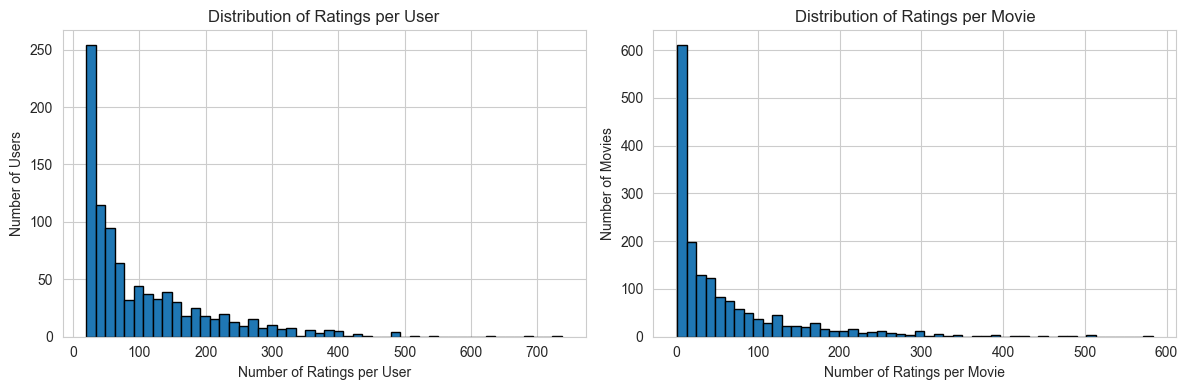


TOP 10 MOST RATED MOVIES
title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
dtype: int64

TOP 10 BEST RATED MOVIES (with at least 50 ratings)
                                                  title  avg_rating  \
318                               Close Shave, A (1995)    4.491071   
1281                            Schindler's List (1993)    4.466443   
1652                         Wrong Trousers, The (1993)    4.466102   
273                                   Casablanca (1942)    4.456790   
1597  Wallace & Gromit: The Best of Aardman Animatio...    4.447761   
1317                   Shawshank Redemption, The (1994)    4.445230   
1215                               

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================
# STEP 1: Load the ratings data
# ============================================

# The u.data file has columns: userID, movieID, rating, timestamp
# But pandas doesn't know the column names, so we need to tell it
ratings = pd.read_csv(
    'ml-100k/u.data',
    sep='\t',  # values are separated by tabs
    header=None,  # there's no header row
    names=['userId', 'movieId', 'rating', 'timestamp']  # these are the column names
)

print("=" * 50)
print("RATINGS DATA")
print("=" * 50)
print(f"Shape: {ratings.shape}")  # How many rows and columns?
print(f"\nFirst 5 rows:")
print(ratings.head())
print(f"\nData types:")
print(ratings.dtypes)
print(f"\nBasic statistics:")
print(ratings.describe())

# ============================================
# STEP 2: Load the movies data
# ============================================

# The u.item file contains movie information
# Format: movieID | title | release date | video release date | genres...
movies = pd.read_csv(
    'ml-100k/u.item',
    sep='|',  # separated by pipes
    header=None,
    encoding='latin-1',  # special character encoding
    names=['movieId', 'title', 'releaseDate', 'videoReleaseDate', 'url', 
           'unknown', 'action', 'adventure', 'animation', 'childrens', 'comedy', 
           'crime', 'documentary', 'drama', 'fantasy', 'film_noir', 'horror', 
           'musical', 'mystery', 'romance', 'sci_fi', 'thriller', 'war', 'western']
)

print("\n" + "=" * 50)
print("MOVIES DATA")
print("=" * 50)
print(f"Shape: {movies.shape}")
print(f"\nFirst 5 rows:")
print(movies.head())

# ============================================
# STEP 3: Merge ratings with movie info
# ============================================

# Combine ratings with movie titles so we can see what people rated
data = ratings.merge(movies[['movieId', 'title']], on='movieId')

print("\n" + "=" * 50)
print("MERGED DATA (Ratings + Movie Titles)")
print("=" * 50)
print(f"Shape: {data.shape}")
print(f"\nFirst 5 rows:")
print(data.head(10))

# ============================================
# STEP 4: Basic Statistics
# ============================================

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print(f"Number of unique users: {ratings['userId'].nunique()}")
print(f"Number of unique movies: {ratings['movieId'].nunique()}")
print(f"Number of ratings: {len(ratings)}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print(f"Rating range: {ratings['rating'].min()} - {ratings['rating'].max()}")

# ============================================
# STEP 5: Visualization
# ============================================

# How many ratings does each user give?
user_ratings_count = ratings.groupby('userId').size()
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(user_ratings_count, bins=50, edgecolor='black')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.title('Distribution of Ratings per User')

# How many ratings does each movie get?
plt.subplot(1, 2, 2)
movie_ratings_count = ratings.groupby('movieId').size()
plt.hist(movie_ratings_count, bins=50, edgecolor='black')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies')
plt.title('Distribution of Ratings per Movie')

plt.tight_layout()
plt.show()

# Most rated movies
print("\n" + "=" * 50)
print("TOP 10 MOST RATED MOVIES")
print("=" * 50)
top_movies = data.groupby('title').size().sort_values(ascending=False).head(10)
print(top_movies)

# Average rating by movie
print("\n" + "=" * 50)
print("TOP 10 BEST RATED MOVIES (with at least 50 ratings)")
print("=" * 50)
movie_avg_rating = data.groupby('title').agg({
    'rating': ['mean', 'count']
}).reset_index()
movie_avg_rating.columns = ['title', 'avg_rating', 'num_ratings']
movie_avg_rating = movie_avg_rating[movie_avg_rating['num_ratings'] >= 50]
movie_avg_rating = movie_avg_rating.sort_values('avg_rating', ascending=False)
print(movie_avg_rating.head(10))

In [4]:
# ============================================
# PART 2: CONTENT-BASED RECOMMENDER
# ============================================

# Step 1: Create a genre matrix (which movies have which genres)
# We'll use the movies data with all the genre columns

print("=" * 50)
print("BUILDING CONTENT-BASED RECOMMENDER")
print("=" * 50)

# Get the genre columns (they're binary: 0 or 1)
genre_columns = ['unknown', 'action', 'adventure', 'animation', 'childrens', 'comedy', 
                 'crime', 'documentary', 'drama', 'fantasy', 'film_noir', 'horror', 
                 'musical', 'mystery', 'romance', 'sci_fi', 'thriller', 'war', 'western']

# Create a matrix: each row is a movie, each column is a genre
movie_genres = movies[['movieId', 'title'] + genre_columns].copy()

print(f"\nMovie-Genre Matrix Shape: {movie_genres.shape}")
print(f"\nFirst 5 movies and their genres:")
print(movie_genres.head())

# Step 2: Calculate similarity between movies using cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

# Get just the genre values (not the movieId and title)
genre_matrix = movie_genres[genre_columns].values

# Calculate cosine similarity between all movies
# This tells us: "How similar is Movie A to Movie B?"
similarity_matrix = cosine_similarity(genre_matrix)

print(f"\nSimilarity Matrix Shape: {similarity_matrix.shape}")
print("(This means we can compare any of 1,682 movies to any other movie)")

# Step 3: Create a recommendation function
def recommend_movies(movie_title, n_recommendations=5):
    """
    Recommend movies similar to the given movie_title

    Parameters:
    - movie_title: The name of the movie to base recommendations on
    - n_recommendations: How many movies to recommend (default: 5)

    Returns:
    - List of recommended movie titles with similarity scores
    """

    # Find the movie ID from the title
    try:
        movie_idx = movies[movies['title'] == movie_title].index[0]
    except IndexError:
        return f"❌ Movie '{movie_title}' not found in database"

    # Get the similarity scores for this movie vs all other movies
    similarity_scores = similarity_matrix[movie_idx]

    # Get the indices of the most similar movies (excluding the movie itself)
    similar_movie_indices = similarity_scores.argsort()[-n_recommendations-1:-1][::-1]

    # Get the movie titles and scores
    recommended_movies = []
    for idx in similar_movie_indices:
        movie_name = movies.iloc[idx]['title']
        score = similarity_scores[idx]
        recommended_movies.append({
            'title': movie_name,
            'similarity_score': score
        })

    return recommended_movies

# Step 4: Test the recommender!
print("\n" + "=" * 50)
print("TESTING THE RECOMMENDER")
print("=" * 50)

# Let's find some popular movies first
popular_movies = data.groupby('title').size().sort_values(ascending=False).head(10).index.tolist()

print(f"\nTop 10 most-rated movies in the database:")
for i, movie in enumerate(popular_movies, 1):
    print(f"{i}. {movie}")

# Test with the first popular movie
test_movie = popular_movies[0]
print(f"\n\n{'*' * 50}")
print(f"RECOMMENDATIONS FOR: '{test_movie}'")
print(f"{'*' * 50}")

recommendations = recommend_movies(test_movie, n_recommendations=5)

for i, rec in enumerate(recommendations, 1):
    score = rec['similarity_score']
    print(f"{i}. {rec['title']} (Similarity: {score:.3f})")

BUILDING CONTENT-BASED RECOMMENDER

Movie-Genre Matrix Shape: (1682, 21)

First 5 movies and their genres:
   movieId              title  unknown  action  adventure  animation  \
0        1   Toy Story (1995)        0       0          0          1   
1        2   GoldenEye (1995)        0       1          1          0   
2        3  Four Rooms (1995)        0       0          0          0   
3        4  Get Shorty (1995)        0       1          0          0   
4        5     Copycat (1995)        0       0          0          0   

   childrens  comedy  crime  documentary  ...  fantasy  film_noir  horror  \
0          1       1      0            0  ...        0          0       0   
1          0       0      0            0  ...        0          0       0   
2          0       0      0            0  ...        0          0       0   
3          0       1      0            0  ...        0          0       0   
4          0       0      1            0  ...        0          0       0  

In [5]:
def recommend_movies_improved(movie_title, n_recommendations=5):
    """
    Recommend movies similar to the given movie_title
    (IMPROVED: excludes the movie itself)
    """

    try:
        movie_idx = movies[movies['title'] == movie_title].index[0]
    except IndexError:
        return f"❌ Movie '{movie_title}' not found in database"

    similarity_scores = similarity_matrix[movie_idx]

    # Get indices of most similar movies, EXCLUDING the movie itself
    # We use n_recommendations + 2 to account for excluding the original
    similar_movie_indices = similarity_scores.argsort()[-n_recommendations-2:-2][::-1]

    recommended_movies = []
    for idx in similar_movie_indices:
        movie_name = movies.iloc[idx]['title']
        score = similarity_scores[idx]
        recommended_movies.append({
            'title': movie_name,
            'similarity_score': score
        })

    return recommended_movies


# Test the improved version
print("\n" + "=" * 60)
print("IMPROVED RECOMMENDATIONS (Without the original movie)")
print("=" * 60)

test_movies = ['Star Wars (1977)', 'Toy Story (1995)', 'Scream (1996)']

for test_movie in test_movies:
    print(f"\n📽️  RECOMMENDATIONS FOR: '{test_movie}'")
    print("-" * 60)

    recommendations = recommend_movies_improved(test_movie, n_recommendations=5)

    if isinstance(recommendations, str):
        print(recommendations)
    else:
        for i, rec in enumerate(recommendations, 1):
            score = rec['similarity_score']
            print(f"  {i}. {rec['title']} (Similarity: {score:.3f})")


IMPROVED RECOMMENDATIONS (Without the original movie)

📽️  RECOMMENDATIONS FOR: 'Star Wars (1977)'
------------------------------------------------------------
  1. Empire Strikes Back, The (1980) (Similarity: 0.913)
  2. Starship Troopers (1997) (Similarity: 0.894)
  3. African Queen, The (1951) (Similarity: 0.894)
  4. Star Trek: First Contact (1996) (Similarity: 0.775)
  5. Time Tracers (1995) (Similarity: 0.775)

📽️  RECOMMENDATIONS FOR: 'Toy Story (1995)'
------------------------------------------------------------
  1. Aladdin (1992) (Similarity: 0.866)
  2. Goofy Movie, A (1995) (Similarity: 0.866)
  3. Home Alone 3 (1997) (Similarity: 0.816)
  4. Land Before Time III: The Time of the Great Giving (1995) (V) (Similarity: 0.816)
  5. Angels in the Outfield (1994) (Similarity: 0.816)

📽️  RECOMMENDATIONS FOR: 'Scream (1996)'
------------------------------------------------------------
  1. Nightwatch (1997) (Similarity: 1.000)
  2. Relative Fear (1994) (Similarity: 1.000)
  3. Th

In [6]:
print("\n" + "=" * 70)
print("PART 3: COLLABORATIVE FILTERING RECOMMENDER")
print("=" * 70)

# Step 1: Create a User-Movie Rating Matrix
# Rows = Users, Columns = Movies, Values = Ratings

print("\nCreating User-Movie Rating Matrix...")
user_movie_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

print(f"User-Movie Matrix Shape: {user_movie_matrix.shape}")
print(f"  - {user_movie_matrix.shape[0]} users")
print(f"  - {user_movie_matrix.shape[1]} movies")
print(f"  - {user_movie_matrix.isnull().sum().sum()} missing values (movies not rated)")

# The matrix looks like this:
#         movieId  1    2    3    4    5
#         userId
#         1       5.0  NaN  4.0  NaN  4.0
#         2       3.0  4.0  NaN  5.0  NaN
#         3       4.0  NaN  3.0  4.0  5.0

print(f"\nFirst 5x10 of the matrix (previewing):")
print(user_movie_matrix.iloc[:5, :10])

# Step 2: Fill NaN values with 0 (movies not rated = 0)
# This is a simplification, but it works for finding patterns
user_movie_matrix_filled = user_movie_matrix.fillna(0)

# Step 3: Calculate user-to-user similarity
# Similar users = users who rated movies similarly
from sklearn.metrics.pairwise import cosine_similarity

print("\nCalculating user-to-user similarity...")
user_similarity = cosine_similarity(user_movie_matrix_filled)

print(f"User Similarity Matrix Shape: {user_similarity.shape}")
print(f"(We can compare any of {user_similarity.shape[0]} users to any other user)")

# Step 4: Create collaborative filtering recommendation function
def recommend_movies_collaborative(user_id, n_recommendations=5):
    """
    Recommend movies for a user based on what similar users liked

    Logic:
    1. Find users similar to this user
    2. Look at movies those users rated highly
    3. Recommend movies this user hasn't rated yet
    """

    if user_id not in ratings['userId'].values:
        return f"❌ User {user_id} not found in database"

    # Get user index (pandas index, not user ID)
    user_idx = user_id - 1  # User IDs start at 1, but pandas index starts at 0

    # Get similarity scores between this user and all other users
    similarity_scores = user_similarity[user_idx]

    # Get the indices of most similar users (excluding the user themselves)
    similar_user_indices = similarity_scores.argsort()[-11:-1][::-1]  # Top 10 similar users

    # Get movies rated by similar users
    similar_users = [idx + 1 for idx in similar_user_indices]  # Convert back to user IDs

    # Find movies that similar users rated highly (4+ stars)
    movies_rated_by_similar = ratings[
        (ratings['userId'].isin(similar_users)) & 
        (ratings['rating'] >= 4)  # Only highly-rated movies
    ].copy()

    # Filter out movies the current user has already rated
    user_rated_movies = set(ratings[ratings['userId'] == user_id]['movieId'].values)
    recommended_movie_ids = movies_rated_by_similar[
        ~movies_rated_by_similar['movieId'].isin(user_rated_movies)
    ]['movieId'].values

    # Get the most frequently recommended movies
    movie_recommendation_counts = {}
    for movie_id in recommended_movie_ids:
        movie_recommendation_counts[movie_id] = movie_recommendation_counts.get(movie_id, 0) + 1

    # Sort by count (popularity among similar users)
    top_movie_ids = sorted(
        movie_recommendation_counts.items(), 
        key=lambda x: x[1], 
        reverse=True
    )[:n_recommendations]

    # Convert to movie titles with scores
    recommendations = []
    for movie_id, count in top_movie_ids:
        movie_title = movies[movies['movieId'] == movie_id]['title'].values[0]
        recommendations.append({
            'title': movie_title,
            'recommendation_score': count
        })

    return recommendations


# Step 5: Test Collaborative Filtering
print("\n" + "=" * 70)
print("TESTING COLLABORATIVE FILTERING")
print("=" * 70)

# Test with a few different users
test_users = [1, 5, 10]

for test_user in test_users:
    print(f"\n👤 RECOMMENDATIONS FOR USER {test_user}")
    print("-" * 70)

    # Get what this user has rated
    user_ratings = ratings[ratings['userId'] == test_user]
    print(f"   This user has rated {len(user_ratings)} movies")

    # Get recommendations
    recommendations = recommend_movies_collaborative(test_user, n_recommendations=5)

    if isinstance(recommendations, str):
        print(recommendations)
    else:
        if len(recommendations) == 0:
            print("   No recommendations available (user may have rated all movies!)")
        else:
            for i, rec in enumerate(recommendations, 1):
                score = rec['recommendation_score']
                print(f"   {i}. {rec['title']} (Recommended by {score} similar users)")


PART 3: COLLABORATIVE FILTERING RECOMMENDER

Creating User-Movie Rating Matrix...
User-Movie Matrix Shape: (943, 1682)
  - 943 users
  - 1682 movies
  - 1486126 missing values (movies not rated)

First 5x10 of the matrix (previewing):
movieId   1    2    3    4    5    6    7    8    9    10
userId                                                   
1        5.0  3.0  4.0  3.0  3.0  5.0  4.0  1.0  5.0  3.0
2        4.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  2.0
3        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
4        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
5        4.0  3.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN

Calculating user-to-user similarity...
User Similarity Matrix Shape: (943, 943)
(We can compare any of 943 users to any other user)

TESTING COLLABORATIVE FILTERING

👤 RECOMMENDATIONS FOR USER 1
----------------------------------------------------------------------
   This user has rated 272 movies
   1. Dr. Strangelove or: How I Learned to Stop Worrying 

In [7]:
print("\n" + "=" * 70)
print("PART 4: HYBRID RECOMMENDER (Best of Both Worlds!)")
print("=" * 70)

def recommend_movies_hybrid(user_id, movie_title=None, n_recommendations=5, 
                           content_weight=0.4, collaborative_weight=0.6):
    """
    Hybrid recommender combining:
    - Content-Based (genre similarity)
    - Collaborative Filtering (user similarity)

    Parameters:
    - user_id: The user to recommend for
    - movie_title: Optional - base recommendations on a specific movie too
    - content_weight: How much to weigh genre similarity (0-1)
    - collaborative_weight: How much to weigh user ratings (0-1)
    """

    # Get collaborative filtering recommendations
    collab_recommendations = recommend_movies_collaborative(user_id, n_recommendations=10)

    if isinstance(collab_recommendations, str):
        return collab_recommendations

    collab_movie_titles = {rec['title']: rec['recommendation_score'] for rec in collab_recommendations}

    # Get content-based recommendations if a movie is specified
    if movie_title:
        content_recommendations = recommend_movies_improved(movie_title, n_recommendations=10)
        if isinstance(content_recommendations, str):
            return f"Error with content-based: {content_recommendations}"

        content_movie_titles = {rec['title']: rec['similarity_score'] for rec in content_recommendations}
    else:
        content_movie_titles = {}

    # Combine scores
    combined_scores = {}

    # Add collaborative scores
    for title, score in collab_movie_titles.items():
        combined_scores[title] = collaborative_weight * (score / 10.0)  # Normalize

    # Add content scores
    for title, score in content_movie_titles.items():
        if title in combined_scores:
            combined_scores[title] += content_weight * score
        else:
            combined_scores[title] = content_weight * score

    # Sort and get top N
    top_recommendations = sorted(
        combined_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:n_recommendations]

    return [{'title': title, 'hybrid_score': score} for title, score in top_recommendations]


# Test Hybrid Recommender
print("\nTesting HYBRID RECOMMENDER")
print("=" * 70)

print("\n🎬 HYBRID RECOMMENDATIONS FOR USER 1")
print("   (Using collaborative + content-based)")
print("-" * 70)

hybrid_recs = recommend_movies_hybrid(user_id=1, n_recommendations=5, 
                                      collaborative_weight=0.7, 
                                      content_weight=0.3)

for i, rec in enumerate(hybrid_recs, 1):
    print(f"   {i}. {rec['title']} (Score: {rec['hybrid_score']:.3f})")


# COMPARISON: Let's compare all three approaches for the same user
print("\n\n" + "=" * 70)
print("COMPARING ALL THREE APPROACHES")
print("=" * 70)

test_user = 1
test_movie = "Star Wars (1977)"

print(f"\n🎯 Recommendations for USER {test_user}")
print(f"   (Taking Star Wars as a reference movie)")
print("-" * 70)

# Content-Based
print("\n1️⃣  CONTENT-BASED (Similar genres to Star Wars):")
content_recs = recommend_movies_improved(test_movie, n_recommendations=3)
for i, rec in enumerate(content_recs, 1):
    print(f"   {i}. {rec['title']}")

# Collaborative
print("\n2️⃣  COLLABORATIVE (What users like User 1 rated highly):")
collab_recs = recommend_movies_collaborative(test_user, n_recommendations=3)
for i, rec in enumerate(collab_recs, 1):
    print(f"   {i}. {rec['title']}")

# Hybrid
print("\n3️⃣  HYBRID (Combining both approaches):")
hybrid_recs = recommend_movies_hybrid(user_id=test_user, movie_title=test_movie, 
                                      n_recommendations=3)
for i, rec in enumerate(hybrid_recs, 1):
    print(f"   {i}. {rec['title']}")

print("\n" + "=" * 70)
print("ANALYSIS:")
print("=" * 70)
print("""
✅ Content-Based: Good for similar movies but ignores user preferences
✅ Collaborative: Good for personalized recommendations but ignores item similarity
✅ Hybrid: Combines both for better, more balanced recommendations!
""")


PART 4: HYBRID RECOMMENDER (Best of Both Worlds!)

Testing HYBRID RECOMMENDER

🎬 HYBRID RECOMMENDATIONS FOR USER 1
   (Using collaborative + content-based)
----------------------------------------------------------------------
   1. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963) (Score: 0.560)
   2. One Flew Over the Cuckoo's Nest (1975) (Score: 0.560)
   3. Schindler's List (1993) (Score: 0.560)
   4. Batman (1989) (Score: 0.560)
   5. Shine (1996) (Score: 0.490)


COMPARING ALL THREE APPROACHES

🎯 Recommendations for USER 1
   (Taking Star Wars as a reference movie)
----------------------------------------------------------------------

1️⃣  CONTENT-BASED (Similar genres to Star Wars):
   1. Empire Strikes Back, The (1980)
   2. Starship Troopers (1997)
   3. African Queen, The (1951)

2️⃣  COLLABORATIVE (What users like User 1 rated highly):
   1. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)
   2. One Flew Over the Cuckoo'